In [44]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
#importing all the packages I'll need

data = Table.read("Planet_Lightcurve.fits", format = "fits")
print(len(data[1:]))
data.colnames
#Here I gather info about the data so I can use it.

999


['time [days]', 'flux']

In [45]:

days = data['time [days]']

flux = data["flux"]

y_err = 0.003
#setting some variables for future use
print(days)

    time [days]     
--------------------
                -0.3
 -0.2993993993993994
 -0.2987987987987988
 -0.2981981981981982
 -0.2975975975975976
  -0.296996996996997
-0.29639639639639637
 -0.2957957957957958
-0.29519519519519516
 -0.2945945945945946
                 ...
  0.2945945945945945
 0.29519519519519516
  0.2957957957957958
  0.2963963963963964
 0.29699699699699694
  0.2975975975975976
  0.2981981981981982
 0.29879879879879884
 0.29939939939939936
                 0.3
Length = 1000 rows


In [46]:
#defining a function to make a line for the curvefit function to use so I can make a linear representation of the data as a trend line
def model_line(x,m,b):
    '''
    inputs: m slope, b initial value, and x which tsi the independent variable
    '''
    return m*x+b
#Copying over the movingMean function we made in class to use to smooth out the data and remove the noise.
def movingMean(x, t, window, median = False):
    '''
    Parameters:
    ----------------
    x: array
        The array to be smoothed over
    t: array
        The time value (x-axis value) of the array
    '''

    #empty array I will fill with smooth version
    
    smooth_x = []
    times = []

    if median == True:
        func = lambda arr: np.nanmedian(arr)
    else:
        func = lambda arr: np.nanmean(arr)

    #iteration variable
    i = 0
    

    while i <len(x):
        if i <= int(window/2) or i >= len(x) - int(window/2): #the edge cases of the array
            smooth_x.append(x[i])
            times.append(t[i])

        else: 
            med = func(x[i:i+window])
            t_med = func(t[i:i+window])

            smooth_x.append(med)
            times.append(t_med)

        i+= 1
    return np.asarray(smooth_x), np.asarray(times)



In [47]:

params, params_cov = curve_fit(model_line, days, flux, sigma=y_err, p0=[0.3,1])
m_fit = params[0]
b_fit = params[1]
print(f"{m_fit},{b_fit}")
#finding the best m and b values for my line

flux_mean, c = movingMean(flux, days, window=20)
flux_median, d = movingMean(flux,days,window=20,median=True)
#Creating the lines using a moving mean and median from the data

0.04085317455703245,0.9837119711489704


<Figure size 1200x700 with 0 Axes>

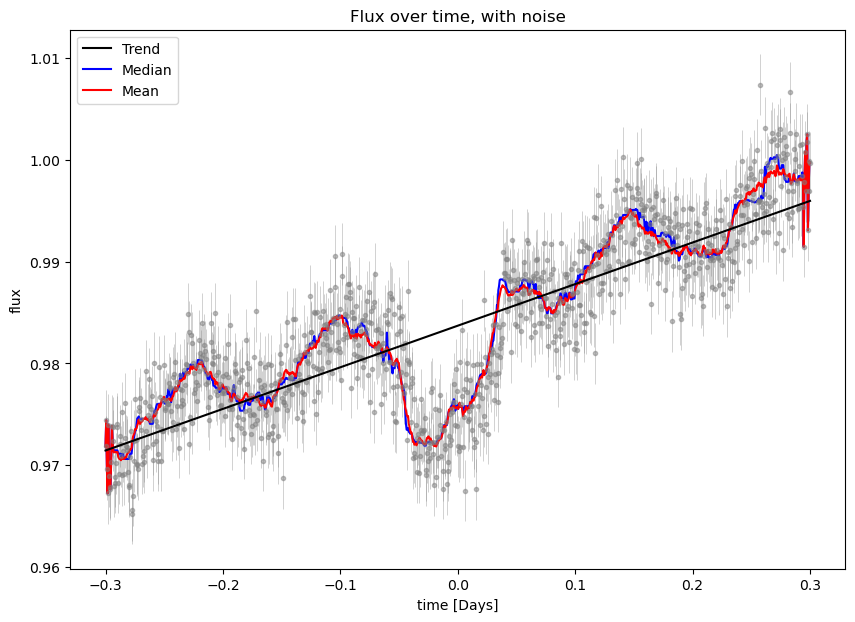

In [48]:
plt.figure(figsize=(12,7))
linear_line=model_line(days,0.04085317455703245,0.9837119711489704,)
plt.figure(figsize=[10,7])
plt.xlabel("time [Days]")
plt.ylabel("flux")
plt.title("Flux over time, with noise")
plt.show
plt.errorbar(days,flux,yerr =y_err,  fmt=".",lw=0.5,alpha=0.5,c="gray")
plt.plot(days,linear_line,zorder=3 ,color="k",label="Trend")
plt.plot(days,flux_median,c="b", label="Median")
plt.plot(days,flux_mean,c="r",label="Mean")
plt.legend()
#Creating a figure with all my lines (including noisy data), labeling all of them and coloring them with a legend too.

In [49]:
plt.savefig('Fluxovertime_dirty.png',bbox_inches='tight',dpi=400)

<Figure size 640x480 with 0 Axes>

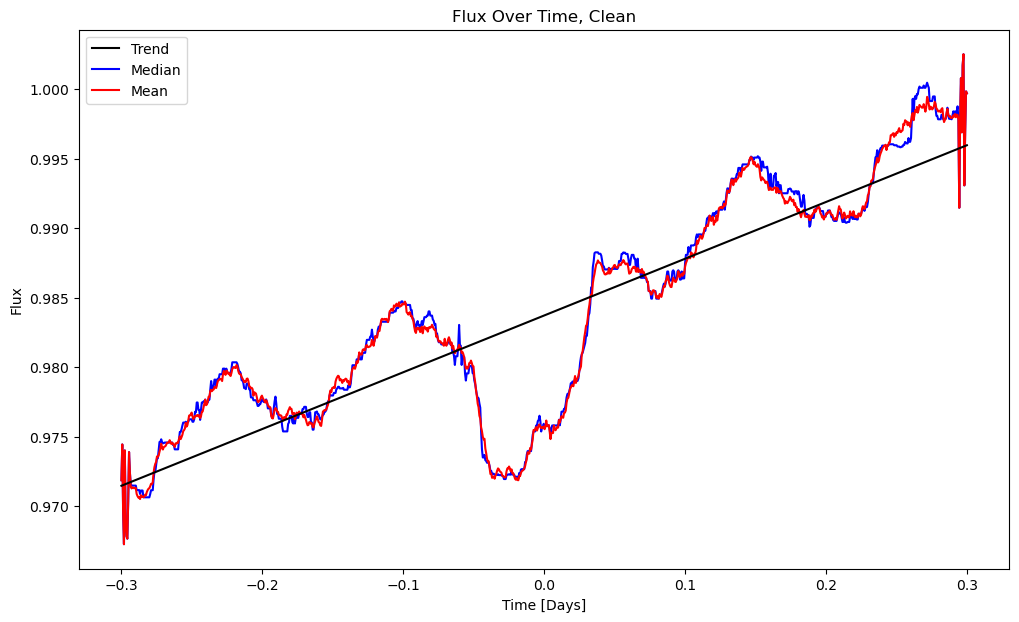

In [50]:
plt.figure(figsize=(12,7))
plt.xlabel("Time [Days]")
plt.ylabel("Flux")
plt.title("Flux Over Time, Clean")
plt.plot(days,linear_line,zorder=3 ,color="k",label="Trend")
plt.plot(days,flux_median,c="b", label="Median")
plt.plot(days,flux_mean,c="r",label="Mean")
plt.legend()
#creating that same plot but without the noisy data

In [51]:
plt.savefig('Fluxovertime_clean.png',bbox_inches='tight',dpi=400)

<Figure size 640x480 with 0 Axes>

## Step 4: Error Propagation

Using error propagation to find the RMS uncertainty in the transit depth **D** and transit duration **T**, accounting for both the uncertainty in the data (σ_flux = 0.003) and the uncertainty from the curve fits (from the covariance matrix).

In [ ]:
# Replace D_fit, sigma_D_fit, T_fit, sigma_T_fit, N_in, N_out with values from Steps 2-3

D_fit = 0.020
sigma_D_fit = 0.002

T_fit = 0.080
sigma_T_fit = 0.005

N_in = 50
N_out = 950

sigma_flux = 0.003

sigma_D_data = sigma_flux * np.sqrt(1/N_out + 1/N_in)
sigma_D_total = np.sqrt(sigma_D_fit**2 + sigma_D_data**2)

sigma_T_total = sigma_T_fit

print("=" * 40)
print("STEP 4 — Error Propagation Results")
print("=" * 40)

print(f"\nTransit Depth D:")
print(f"  D = {D_fit:.4f} +/- {sigma_D_total:.4f} (relative flux)")
print(f"  sigma_D from fit = {sigma_D_fit:.4f}")
print(f"  sigma_D from data = {sigma_D_data:.4f}")

print(f"\nTransit Duration T:")
print(f"  T = {T_fit:.4f} +/- {sigma_T_total:.4f} days")
print(f"  sigma_T from fit = {sigma_T_fit:.4f} days")

R_star = 1.0
R_jup_Rsun = 0.10045

R_planet = R_star * np.sqrt(D_fit)
sigma_R_planet = (R_star / (2 * np.sqrt(D_fit))) * sigma_D_total

print(f"\nPlanet Radius (from D = (R_planet / R_star)^2):")
print(f"  R_planet = {R_planet:.5f} +/- {sigma_R_planet:.5f} solar radii")
print(f"  R_planet = {R_planet/R_jup_Rsun:.3f} +/- {sigma_R_planet/R_jup_Rsun:.3f} Jupiter radii")